# Implementacion de una GRU con atención

Datos de la competencia **MEX-A3T: Fake News and Aggressiveness Analysis** 

In [2]:
import os
import time 
from argparse import Namespace

import torch 
import torch.nn.functional as F 
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pad_packed_sequence, pack_padded_sequence
from tqdm.auto import tqdm

import pandas as pd 
import numpy as np 

from sklearn.metrics import f1_score
import nltk 
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ericl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
os.getcwd()

'C:\\Users\\ericl\\tareas_nlp'

In [4]:
args = Namespace()
args.path_txt_train = r'./tarea_2/data_mex/mex20_train.txt'
args.path_y_train = r'./tarea_2/data_mex/mex20_train_labels.txt' 

args.path_txt_val = r'./tarea_2/data_mex/mex20_val.txt' 
args.path_y_val = r'./tarea_2/data_mex/mex20_val_labels.txt'

args.train = True

## Dataset

In [5]:
class DatasetAgression(Dataset):
    def __init__(self, args):
        super(Dataset,self).__init__()
        if args.train:
            self.load_dataset(args.path_txt_train, args.path_y_train)
        else:
            self.load_dataset(args.path_txt_val, args.path_y_val)
        self.Create_vocab_load_embeddings()
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self,index):
        label = self.df.iloc[index]['target']
        words, words_ids = self.preprocess_text(index)
        return words, words_ids, label

    
    def load_dataset(self, path_txt, path_y):
        file_txt = []
        target_txt = []
        
        with open(path_txt, 'r', encoding="utf8") as f_corpus, open(path_y, 'r', encoding="utf8") as f_target:
            for tweet in f_corpus:
                file_txt.append(tweet.strip())
            for target in f_target:
                target_txt.append(int(target.strip()))
                
        self.df = pd.DataFrame({
            'text': file_txt,
            'target': target_txt
        })
        
        return self.df

    def preprocess_text(self, index):
        text = self.df.iloc[index]['text']
        words = nltk.word_tokenize(text)
        word_ids = [self.vocab[word] if word in self.vocab.keys() else self.emb_mat.shape[0]-1\
                        for word in words]
        return words, word_ids

    def Create_vocab_load_embeddings(self): 
        '''Embeddings preentrenados en twitter.
           emb_mat: Matriz de embeddings. Un vector de tamaño 200 para cada palabra del vocabulario.
           vocab: Diccionario, asigna a cada palabra su renglón correspondiente en la matriz de embeddings.
        '''
        embeddings_list = []
        self.vocab_dict = {}
        self.vocab = {}
        with open('./tarea_5/w2v/word2vec_col.txt', 'r', encoding='utf8', errors='replace') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                values = line.strip().split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32') 
                self.vocab_dict[i+1] = word
                self.vocab[word] = i+1
                embeddings_list.append(vector)
        embeddings_list.insert(0,np.mean(np.vstack(embeddings_list), axis=0))
        embeddings_list.insert(0,np.zeros(100))
        self.vocab_dict[0] = '[PAD]'
        self.vocab_dict[1] = '[UNK]'
        self.vocab['[PAD]'] = 0
        self.vocab['[UNK]'] = 1
        self.emb_mat = np.vstack(embeddings_list)

        return self.vocab, self.emb_mat

    def get_weigths(self):
        '''Devuelve pesos inversos para cada categoría. Mayor peso para la categoría con menos observaciones.'''
        cat_0 = len(self.df[self.df['target']==0])
        cat_1 = len(self.df[self.df['target']==1])
        maxi = max(cat_0, cat_1)
        return torch.tensor([maxi/cat_0, maxi/cat_1])

    def collate_fn(self, batch): 
        "Función para generar los batches al ejecutar el DataLoader"
        # Se separan los elementos de cada muestra
        zipped_batch = list(zip(*batch))
        
        # zipped_batch[0] -> palabras (lista de tokens, strings)
        # zipped_batch[1] -> word_ids (lista de enteros)
        # zipped_batch[2] -> labels (enteros)
        
        # Convertir los word_ids a tensores y luego concatenarlos
        word_ids = [torch.tensor(t) for t in zipped_batch[1]]
        # Es recomendable paddear las secuencias si tienen longitudes diferentes.
        word_ids = torch.nn.utils.rnn.pad_sequence(word_ids, batch_first=True)
        
        # Obtener las longitudes de cada secuencia de word_ids
        lengths = torch.tensor([len(t) for t in zipped_batch[1]])
        
        # Convertir las etiquetas a tensor
        labels = torch.tensor(zipped_batch[2])
        
        # También se pueden retornar las palabras originales si se necesitan
        words = zipped_batch[0]
        
        return word_ids, lengths, labels, words

        

In [174]:
with open('./tarea_5/w2v/word2vec_col.txt', 'r') as f:
    first_line = f.readline().strip().split()
    second_line = f.readline().strip().split()
    print(first_line)
    print(second_line)

['973265', '100']
['de', '-1.64168', '1.447671', '-2.283216', '-1.965226', '-0.222943', '5.105217', '-0.120701', '-0.126822', '-3.177338', '-3.454396', '-0.943083', '-0.094476', '-1.18936', '-0.812092', '-2.572975', '-0.613877', '-2.311841', '1.05097', '5.634725', '-5.827006', '1.237639', '1.071621', '3.822072', '2.395414', '0.169883', '3.256835', '2.897348', '3.274827', '-2.936382', '0.272003', '-1.029505', '-2.617288', '-1.807143', '1.737624', '0.33913', '3.93293', '1.571361', '-4.100074', '4.156816', '1.162366', '-0.552316', '-0.585887', '-4.767187', '0.253338', '-1.124162', '-0.115079', '-5.606624', '2.976579', '4.426022', '1.019932', '3.76072', '-2.298347', '4.416567', '-1.383988', '-1.862506', '0.399053', '-1.09689', '-2.28599', '2.992802', '0.044008', '3.762375', '-6.523126', '0.621278', '2.641829', '-1.924327', '-1.141184', '-3.831767', '0.549591', '2.260839', '-1.318358', '-1.134662', '-3.788221', '-0.775024', '3.956695', '-3.579425', '-4.423733', '4.505686', '0.719133', '-1.3

In [6]:
data_train = DatasetAgression(args)

In [7]:
args.train = False
data_val = DatasetAgression(args)

In [8]:
df_train = data_train.df
df_val = data_val.df

In [9]:
df_train

,text,target
0,@USUARIO @USUARIO @USUARIO Q se puede esperar ...,1
1,@USUARIO La piel nueva siempre arde un poquito...,0
2,Ustedes no se enamoran de mí… por tontas.,1
3,Me las va a pagar esa puta gorda roba tuits...,1
4,@USUARIO LA GENTE ES TONTA PORQUE NO SE DAN CU...,0
...,...,...
5273,Yo sí sería un gobierno autoritario militar ca...,0
5274,Me sorprende lo celosa que soy y lo bien que l...,0
5275,Las alitas de wings army ahora me supieron feas 😐,0
5276,"Me duele la cabeza, me duele el corazón, ching...",1


In [10]:
df_val

,text,target
0,Al perro que se te acerque le parto su madre a...,1
1,@USUARIO @USUARIO Él supo sacar a su familia a...,0
2,@USUARIO Entonces para que quieres estar en su...,1
3,"Que bueno que hoy juega México, porque tú vale...",1
4,Ojalá un día me valgas la misma verga que al v...,0
...,...,...
582,Jaajjajaajajjajajajaajajjajajaajajajaja te pas...,0
583,"Cada vez que me da el síndrome premenstrual, m...",0
584,@USUARIO Si estuvieras aquí podríamos valer ma...,0
585,Mi abuelito dice que en sus tiempos las únicas...,1


In [108]:
training_emb_mat= data_val.emb_mat

In [110]:
training_emb_mat.shape[0]

973267

In [15]:
vocabulario = data_train.vocab

In [16]:
list(vocabulario.keys())[:100]

['de',
 'que',
 'la',
 'a',
 'y',
 'el',
 'no',
 'en',
 'me',
 'to',
 'es',
 'replying',
 'con',
 'se',
 'mi',
 'un',
 'lo',
 'los',
 'por',
 'te',
 'para',
 'las',
 'twitter',
 'una',
 'del',
 'si',
 'ya',
 'como',
 'yo',
 'i',
 'at',
 'm',
 'al',
 'pero',
 'q',
 'tu',
 'esta',
 'todo',
 'hoy',
 'mas',
 'in',
 'pic',
 'le',
 'quiero',
 'cuando',
 'hay',
 'o',
 'mejor',
 'tengo',
 'vida',
 'ahora',
 'su',
 'este',
 'd',
 'bien',
 'ser',
 'nada',
 'voy',
 'estoy',
 'gracias',
 'nos',
 'ver',
 'todos',
 'eso',
 'sin',
 'siempre',
 'muy',
 'jajaja',
 'son',
 'ni',
 'solo',
 'porque',
 'mis',
 'casa',
 'amor',
 'tan',
 'va',
 'dios',
 'san',
 'hace',
 'soy',
 'feliz',
 'tiene',
 'others',
 'hacer',
 'hasta',
 'bueno',
 'dia',
 'vamos',
 'algo',
 'mucho',
 'nunca',
 'buenos',
 'quien',
 'gente',
 'ti',
 'vez',
 'rt',
 'ir',
 'cosas']

## DataLoader

In [111]:
args.input_size = 100
args.hidden_size = 128
args.num_layers =  1
args.dense_hidden_size = 256
args.bidirectional = False
args.batch_size = 128

In [112]:
train_loader = DataLoader(data_train, batch_size=args.batch_size, collate_fn = data_train.collate_fn, shuffle=True)
val_loader = DataLoader(data_val, batch_size=args.batch_size, collate_fn = data_val.collate_fn, shuffle=False)

In [130]:
batch = next(iter(train_loader))
print(f'X (word_ids) shape: {batch[0].shape}')   # Ejemplo: (batch_size, max_seq_length)
print(f'y (labels) shape: {batch[2].shape}')  
print(f'Longitudes shape: {batch[1].shape}')


X (word_ids) shape: torch.Size([128, 42])
y (labels) shape: torch.Size([128])
Longitudes shape: torch.Size([128])


In [139]:
batch[3][0]

['Ya',
 'soy',
 'ese',
 'tipo',
 'de',
 'amiga',
 'que',
 'solo',
 'se',
 'escucha',
 'que',
 'grita',
 ':',
 'putas',
 ',',
 'putas',
 'para',
 'todos',
 '.',
 '#',
 'SorryNotSorry']

## Modelo GRU

In [22]:
class GRU_RNN(nn.Module):
    def __init__(self,
                 args, 
                 embedding_matrix = None):
        super(GRU_RNN, self).__init__()
        if embedding_matrix is not None:
            embedding_tensor = torch.FloatTensor(embedding_matrix)
            self.Embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=False)
        self.gru = nn.GRU(input_size = args.input_size, 
                          hidden_size = args.hidden_size, 
                          num_layers =args.num_layers, 
                          bidirectional = args.bidirectional)
        directions = 2 if args.bidirectional else 1
        # Head Clasificator MLP 
        self.clasifier = nn.Sequential(\
                            nn.Linear(args.hidden_size*directions, args.dense_hidden_size),
                            nn.BatchNorm1d(args.dense_hidden_size),
                            nn.ReLU(),
                            nn.Linear(args.dense_hidden_size, 2))
    
    def forward(self, x, lengths):
        # x: (batch_size, seq_len) -> tras Embedding: (batch_size, seq_len, embed_dim)
        x = self.Embedding(x)
        
        # Empaqueta las secuencias: batch_first=True porque x tiene esa forma
        packed_x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        
        # Procesa con la GRU
        output, hn = self.gru(packed_x)
        
        # Para GRU, hn tiene forma (num_layers * num_directions, batch, hidden_size)
        if self.gru.bidirectional:
            # Si es bidireccional y num_layers es 1, hn tiene forma (2, batch, hidden_size)
            # Concatenamos las salidas de ambas direcciones:
            hn = torch.cat((hn[0], hn[1]), dim=1)  # resultado: (batch, hidden_size*2)
        else:
            # En caso unidireccional, tomamos la última capa (última salida)
            hn = hn[-1]  # (batch, hidden_size)
        
        # Clasificador final
        x = self.clasifier(hn)
        
        # Retornamos el output del clasificador y, si se requiere, scores = None
        return x, None

        

In [101]:
train_loader = DataLoader(data_train, batch_size=args.batch_size, collate_fn = data_train.collate_fn, shuffle=True)
val_loader = DataLoader(data_val, batch_size=args.batch_size, collate_fn = data_val.collate_fn, shuffle=False)

In [25]:
def eval_model(model, dataloader, criterion, device):
    '''Función para evaluar el modelo.'''
    with torch.no_grad():
        model.eval()
        losses = []
        preds = torch.empty(0).long()
        targets = torch.empty(0).long()
        scores_list = []
        words_list = []
        pred_list = []
        for data in tqdm(dataloader):
            torch.cuda.empty_cache()
            seq, seq_len, labels, words = data
            seq, labels = seq.to(device), labels.to(device)
            output, scores = model(seq, seq_len)
            output = F.log_softmax(output, dim=1)
            loss = criterion(output, labels)
            losses.append(loss.item())
            predictions = F.log_softmax(output, dim=1).argmax(1)
            preds = torch.cat([preds, predictions.cpu()], dim=0)
            targets = torch.cat([targets, labels.cpu()], dim=0)
            if scores is not None:
                pred_list += predictions.tolist()
                scores = scores.cpu().squeeze(2).tolist()
                scores_list += scores
                words_list += words

        model.train()
        preds = preds.numpy()
        targets = targets.numpy()
        f1 = f1_score(targets, preds, average='binary')

        return np.mean(losses), f1, scores_list, words_list, pred_list

In [26]:
args.lr = 0.001
args.num_epochs = 10
args.weight_decay=0.0001
args.beta1=0
args.beta2=0.999
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [27]:
model = GRU_RNN(args, embedding_matrix= data_train.emb_mat).to(device)
optimizer = optim.Adam(model.parameters(), 
                       lr=args.lr, 
                       weight_decay=args.weight_decay, 
                       betas = (args.beta1, args.beta2))
weight = data_train.get_weigths().to(device)
criterion = nn.NLLLoss(weight = weight)

In [28]:
import copy

In [29]:
train_loss_history = []
val_loss_history = []
best_val_f1 = 0
for epoch in range(args.num_epochs):
    for data in tqdm(train_loader):
        # Limpia basura de la memoria GPU
        torch.cuda.empty_cache()
        # Reiniciamos el cálculo del gradiente
        optimizer.zero_grad()
        # Desempaca los datos que salen del dataloader
        seq, seq_len, labels, _ = data
        # Mueve los datos al mismo device en el que este el modelo
        seq, labels = seq.to(device), labels.to(device)
        output, _ = model(seq, seq_len)
        output = F.log_softmax(output, dim=1)
        loss = criterion(output, labels)
        # Calcula el gradiente de la pérdida
        loss.backward()
        # Realiza un paso de la optimización
        optimizer.step()
    
    #Evalúa los modelos en los conjuntos de entrenamiento y valuación
    train_loss, train_f1, _, _, _ = eval_model(model, train_loader, criterion, device)
    val_loss, val_f1, _, _, _ = eval_model(model, val_loader, criterion, device)

    
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    
    print('epoch: %d'%(epoch))
    print('train_loss: %5f | val_loss: %5f | train_f1: %5f | val_f1: %5f'%(train_loss, val_loss, train_f1, val_f1)) 
    if val_f1>best_val_f1:
        best_val_f1=val_f1
        best_state_dict=copy.deepcopy(model.state_dict())

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 0
train_loss: 0.525078 | val_loss: 0.552426 | train_f1: 0.611616 | val_f1: 0.593458


  0%|          | 0/42 [00:00<?, ?it/s]

...

epoch: 8
train_loss: 0.176926 | val_loss: 0.703706 | train_f1: 0.843047 | val_f1: 0.635294


  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 9
train_loss: 0.158892 | val_loss: 0.835269 | train_f1: 0.880047 | val_f1: 0.690722


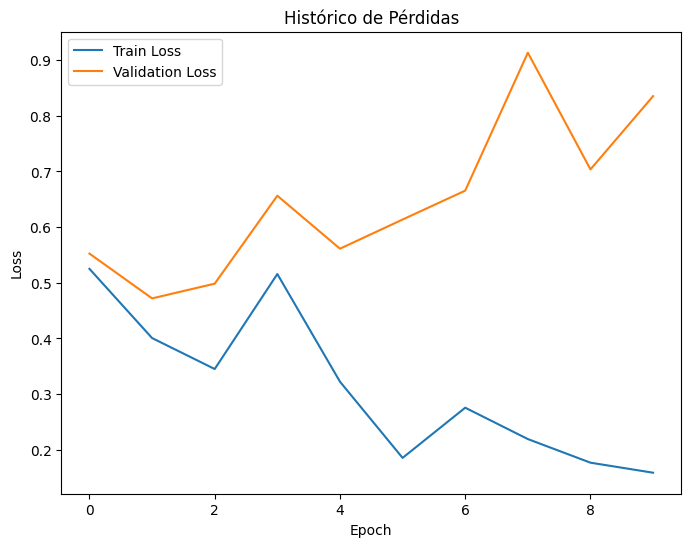

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Histórico de Pérdidas')
plt.legend()
plt.show()

## GRU con Atención

Para calcular la probabilidad condicional de que un modelo como el implementaddo en a seccion [1]

$$
p(y_i \mid y_1, \dots, y_{i-1}, \mathbf{x}) = g(y_{i-1}, s_i, \mathbf{c}_i),
$$

Consideramos que cada estado oculto de la RNN al timpo $t$ $s_i$ es calculado como: 

$$
s_i = f(s_{i-1}, y_{i-1}, \mathbf{c}_i).
$$

Donde la probabilidad es condicionada en el vector $c_i$ para cada palabra de salida $y_i$. El vector de contexto es

$$
\mathbf{c}_i = \sum_{j=1}^{T_x} \alpha_{ij} \mathbf{h}_j.
$$



$$
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})},
$$

$$
e_{ij} = a(s_{i-1}, h_j)
$$

Donde $e_{ij}$ scores que tanto hacen match los inputs al rededor del estado oculto. 

Para nuestro caso consideramos la función $e_{ij}$ es aprendida por una red neuronal. 

$$
e_{t} = \tanh(Wh_{t}+b) 
$$

para calcular los scores entonces usamos  $(e_{t} \cdot e_{t}) = e_{t}^Te_{t}$, por lo que el vector de contexto lo calculamos como


$$
\mathbf{c} = \sum_t \alpha_t h_t
$$

In [49]:
args.attn_hidden_size = 128

In [173]:
#Show parameters hints
# %config IPCompleter.use_jedi = False
# %config Completer.evaluation = 'limited'

In [80]:
class AttentionModule(nn.Module): 
    def __init__(self, args, input_size):
        super(AttentionModule, self).__init__()
        self.fc1 = nn.Linear(in_features=input_size, out_features=args.attn_hidden_size)
        self.fc2 = nn.Linear(in_features=args.attn_hidden_size, out_features=1, bias=False)

    def forward(self, x, lengths):
        '''
        input:
            seq: secuencia de vectores ocultos de la GRU.
            lengths: número de palabras en cada observación.
        '''
        x = pad_packed_sequence(seq)[0]
        seq_len, batch_size, nhid = x.size()
        u = self.fc1(x.view(batch_size*seq_len, nhid))
        u = torch.tanh(u)
        scores = self.fc2(u)
        scores = scores.view(seq_len, batch_size, 1)
        # Asigna -100 a las posiciones con padding para que no sean consideados en la atención.
        scores = nn.utils.rnn.pack_padded_sequence(scores, lengths=lengths,enforce_sorted=False)
        scores = nn.utils.rnn.pad_packed_sequence(scores, padding_value=-100)[0]
        scores = F.softmax(scores, dim=0)
        scores = scores.transpose(0,1)
        x = x.transpose(0,1).transpose(1,2)
        x = torch.bmm(x, scores)
        return x.squeeze(2), scores

In [88]:
class AttnRNN(nn.Module):
    def __init__(self, args, embedding_matrix=None):
        super(AttnRNN, self).__init__()
        self.Embeddings = nn.Embedding.from_pretrained(embeddings=torch.FloatTensor(embedding_matrix), 
                                                      freeze=False)
        self.gru = nn.GRU(input_size = args.input_size, 
                          hidden_size = args.hidden_size, 
                          num_layers =args.num_layers, 
                          bidirectional = args.bidirectional)
        directions = 2 if args.bidirectional else 1
        self.attn = AttentionModule(args, args.hidden_size*directions)
        self.classifier = nn.Sequential(\
                            nn.Linear(args.hidden_size*directions, args.dense_hidden_size),
                            nn.BatchNorm1d(args.dense_hidden_size),
                            nn.ReLU(),
                            nn.Linear(args.dense_hidden_size, 2))
        
    def forward(self, input_seq, lengths):
        x = self.Embeddings(input_seq)
        x = x.split(lengths.tolist())
        x = pad_sequence(x)
        x = pack_padded_sequence(x, lengths, enforce_sorted=False)
        output, hn = self.gru(x)
        x, scores = self.attn(output, lengths)
        x = self.classifier(x)
        return x, scores.detach()

In [92]:
class AttentionModule(nn.Module): 
    def __init__(self, args, input_size):
        super(AttentionModule, self).__init__()
        self.fc1 = nn.Linear(in_features=input_size, out_features=args.attn_hidden_size)
        self.fc2 = nn.Linear(in_features=args.attn_hidden_size, out_features=1, bias=False)

    def forward(self, packed_seq, lengths):
        # Convertimos el PackedSequence a un tensor paddeado.
        x, _ = pad_packed_sequence(packed_seq)  # x: (seq_len, batch_size, hidden_size)
        seq_len, batch_size, hidden_size = x.size()
        
        # Calculamos scores de atención para cada vector en la secuencia.
        u = self.fc1(x.view(-1, hidden_size))   # (batch_size*seq_len, attn_hidden_size)
        u = torch.tanh(u)
        scores = self.fc2(u).view(seq_len, batch_size, 1)  # (seq_len, batch_size, 1)
        
        # Empaquetamos y desempacamos para aplicar padding en posiciones de padding
        scores_packed = pack_padded_sequence(scores, lengths, enforce_sorted=False)
        scores, _ = pad_packed_sequence(scores_packed, padding_value=-100)
        
        # Aplicamos softmax a lo largo de la dimensión temporal (seq_len)
        scores = F.softmax(scores, dim=0)  # (seq_len, batch_size, 1)
        scores = scores.transpose(0, 1)    # (batch_size, seq_len, 1)
        
        # Preparamos el tensor x para la multiplicación por lotes
        x = x.transpose(0, 1).transpose(1, 2)  # (batch_size, hidden_size, seq_len)
        context = torch.bmm(x, scores)          # (batch_size, hidden_size, 1)
        
        return context.squeeze(2), scores

class AttnRNN(nn.Module):
    def __init__(self, args, embedding_matrix=None):
        super(AttnRNN, self).__init__()
        self.Embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=False)
        self.gru = nn.GRU(input_size=args.input_size, 
                          hidden_size=args.hidden_size, 
                          num_layers=args.num_layers, 
                          bidirectional=args.bidirectional)
        directions = 2 if args.bidirectional else 1
        self.attn = AttentionModule(args, args.hidden_size * directions)
        self.classifier = nn.Sequential(
            nn.Linear(args.hidden_size * directions, args.dense_hidden_size),
            nn.BatchNorm1d(args.dense_hidden_size),
            nn.ReLU(),
            nn.Linear(args.dense_hidden_size, 2)
        )
        
    def forward(self, input_seq, lengths):
        # input_seq: (batch_size, seq_len)
        x = self.Embeddings(input_seq)  # (batch_size, seq_len, embed_dim)
        
        # Transponemos para adecuarlo a la GRU que espera (seq_len, batch_size, embed_dim)
        x = x.transpose(0, 1)  # (seq_len, batch_size, embed_dim)
        
        # Empaquetamos las secuencias usando las longitudes reales
        packed_x = pack_padded_sequence(x, lengths, enforce_sorted=False)
        
        # Pasamos el PackedSequence por la GRU
        output, hn = self.gru(packed_x)
        
        # Se aplica el módulo de atención a la salida empaquetada de la GRU
        context, scores = self.attn(output, lengths)
        
        # El clasificador trabaja sobre el vector de contexto obtenido de la atención
        x = self.classifier(context)
        
        return x, scores.detach()


In [96]:
args.lr = 0.0001
args.num_epochs = 20
args.weight_decay=0.0001
args.beta1=0
args.beta2=0.999
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [142]:
def eval_model(model, dataloader, criterion, device):
    '''Función para evaluar el modelo.'''
    with torch.no_grad():
        model.eval()
        losses = []
        preds = torch.empty(0).long()
        targets = torch.empty(0).long()
        scores_list = []
        words_list = []
        pred_list = []
        for data in tqdm(dataloader):
            torch.cuda.empty_cache()
            seq, seq_len, labels, words = data
            seq, labels = seq.to(device), labels.to(device)
            output, scores = model(seq, seq_len)
            output = F.log_softmax(output, dim=1)
            loss = criterion(output, labels)
            losses.append(loss.item())
            predictions = F.log_softmax(output, dim=1).argmax(1)
            preds = torch.cat([preds, predictions.cpu()], dim=0)
            targets = torch.cat([targets, labels.cpu()], dim=0)
            if scores is not None:
                pred_list += predictions.tolist()
                scores = scores.cpu().squeeze(2).tolist()
                scores_list += scores
                words_list += words

        model.train()
        preds = preds.numpy()
        targets = targets.numpy()
        f1 = f1_score(targets, preds, average='binary')

        # Se retorna targets (train_true) además de los otros valores.
        return np.mean(losses), f1, scores_list, words_list, pred_list, targets


In [73]:
data_train

In [143]:
model = AttnRNN(args, embedding_matrix = data_train.emb_mat).to(device)
optimizer = optim.Adam(model.parameters(), lr=args.lr,weight_decay=args.weight_decay, betas = (args.beta1, args.beta2))
weight = data_train.get_weigths().to(device)
criterion = nn.NLLLoss(weight = weight)

In [145]:
train_loss_history = []
val_loss_history = []
best_val_f1 = 0
for epoch in range(args.num_epochs):
    for data in tqdm(train_loader):
        # Limpia basura de la memoria GPU
        torch.cuda.empty_cache()
        # Reiniciamos el cálculo del gradiente
        optimizer.zero_grad()
        # Desempaca los datos que salen del dataloader
        seq, seq_len, labels, _ = data
        # Mueve los datos al mismo device en el que este el modelo
        seq, labels = seq.to(device), labels.to(device)
        output, _ = model(seq, seq_len)
        output = F.log_softmax(output, dim=1)
        loss = criterion(output, labels)
        # Calcula el gradiente de la pérdida
        loss.backward()
        # Realiza un paso de la optimización
        optimizer.step()
    
    #Evalúa los modelos en los conjuntos de entrenamiento y valuación
    train_loss, train_f1, _, _, _, _ = eval_model(model, train_loader, criterion, device)
    val_loss, val_f1, _, _, _, _ = eval_model(model, val_loader, criterion, device)

    
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    
    print('epoch: %d'%(epoch))
    print('train_loss: %5f | val_loss: %5f | train_f1: %5f | val_f1: %5f'%(train_loss, val_loss, train_f1, val_f1)) 
    if val_f1>best_val_f1:
        best_val_f1=val_f1
        best_state_dict=copy.deepcopy(model.state_dict())

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 0
train_loss: 0.518567 | val_loss: 0.539221 | train_f1: 0.628122 | val_f1: 0.620000


  0%|          | 0/42 [00:00<?, ?it/s]

...

epoch: 18
train_loss: 0.253619 | val_loss: 0.497280 | train_f1: 0.862058 | val_f1: 0.674847


  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 19
train_loss: 0.227558 | val_loss: 0.491513 | train_f1: 0.864882 | val_f1: 0.674627


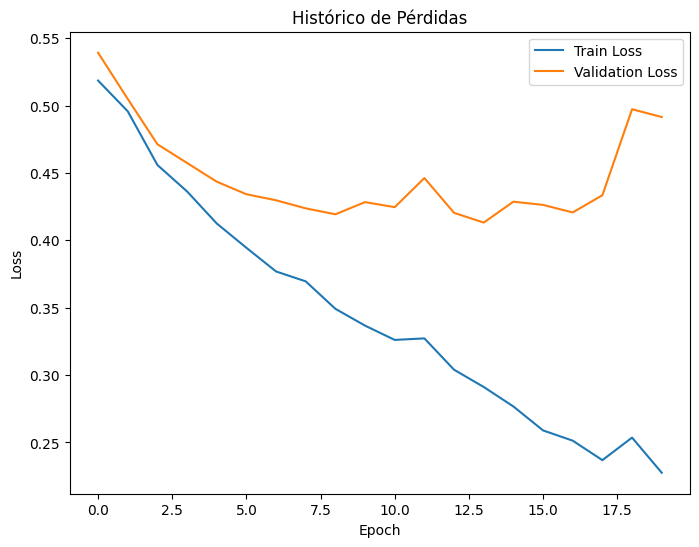

In [146]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Histórico de Pérdidas')
plt.legend()
plt.show()

In [147]:
model.load_state_dict(best_state_dict)
train_loss, train_f1, train_scores, train_words, train_pred, train_true = eval_model(model, train_loader, criterion, device)
val_loss, val_f1, val_scores, val_words, val_pred, val_true = eval_model(model, val_loader, criterion, device)

print('train_loss: %5f | train_f1: %5f' % (train_loss, train_f1))
print('val_loss: %5f | val_f1: %5f' % (val_loss, val_f1))

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

train_loss: 0.330808 | train_f1: 0.788775
val_loss: 0.424616 | val_f1: 0.704918


In [148]:
from IPython.display import display, HTML
import matplotlib
import matplotlib.pyplot as plt

In [149]:
def colorize(words, color_array):
    '''
        Función para visuzalizar la atención, tomada de https://gist.github.com/ihsgnef/f13c35cd46624c8f458a4d23589ac768,
    '''
    # words is a list of words
    # color_array is an array of numbers between 0 and 1 of length equal to words
    cmap = matplotlib.cm.get_cmap('Reds')
    template = '<span class="barcode"; style="color: black; background-color: {}">{}</span>'
    colored_string = ''
    for word, color in zip(words, color_array):
        color = matplotlib.colors.rgb2hex(cmap(color)[:3])
        colored_string += template.format(color, '&nbsp' + word + '&nbsp')
    return colored_string

In [106]:
att = np.linspace(0,1,50)
p = [' ']*50
s = colorize(p, att)
# to display in ipython notebook
display(HTML(s))

C:\Users\ericl\AppData\Local\Temp\ipykernel_23368\2656899777.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')


In [150]:
max_attn = [np.max(scores) for scores in train_scores]
maxi = np.flip(np.argsort(max_attn))
for j in range(30):
    i = maxi[j]
    s = colorize(train_words[i], train_scores[i][:len(train_words[i])])
    # to display in ipython notebook
    category = 'Agresivo' if train_pred[maxi[j]]==1 else 'No agresivo'
    print('Categoría predicha: %s'%(category))
    display(HTML(s))

Categoría predicha: Agresivo


C:\Users\ericl\AppData\Local\Temp\ipykernel_23368\2656899777.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')


Categoría predicha: Agresivo


Categoría predicha: No agresivo


Categoría predicha: Agresivo


...

Categoría predicha: Agresivo


Categoría predicha: Agresivo


Categoría predicha: Agresivo


Categoría predicha: No agresivo


Categoría predicha: Agresivo


In [162]:
incorrect_idx = [i for i in range(len(val_pred)) 
                 if int(val_pred[i]) != int(val_true[i])]

# Para cada ejemplo incorrecto, obtenemos la máxima atención (para poder ordenarlos)
max_attn_incorrect = [np.max(val_scores[i]) for i in incorrect_idx]

# Ordenamos los índices de los ejemplos incorrectos en forma descendente según su máxima atención
order_incorrect = np.argsort(max_attn_incorrect)[::-1]

for j in range(min(30, len(order_incorrect))):
    idx = incorrect_idx[order_incorrect[j]]
    s = colorize(train_words[idx], train_scores[idx][:len(val_words[idx])])
    pred_label = int(val_pred[idx])
    true_label = int(val_true[idx])
    predicted_category = 'Agresivo' if pred_label == 1 else 'No agresivo'
    true_category = 'Agresivo' if true_label == 1 else 'No agresivo'
    print(f'Predicción: {predicted_category}, Etiqueta real: {true_category}')
    display(HTML(s))

Predicción: Agresivo, Etiqueta real: No agresivo


C:\Users\ericl\AppData\Local\Temp\ipykernel_23368\2656899777.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')


Predicción: Agresivo, Etiqueta real: No agresivo


Predicción: No agresivo, Etiqueta real: Agresivo


Predicción: Agresivo, Etiqueta real: No agresivo


...

Predicción: No agresivo, Etiqueta real: Agresivo


Predicción: Agresivo, Etiqueta real: No agresivo


Predicción: No agresivo, Etiqueta real: Agresivo


Predicción: Agresivo, Etiqueta real: No agresivo


Predicción: No agresivo, Etiqueta real: Agresivo
